In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

ModuleNotFoundError: No module named 'seaborn'

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df_null = df.isnull().sum()
print(df_null)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


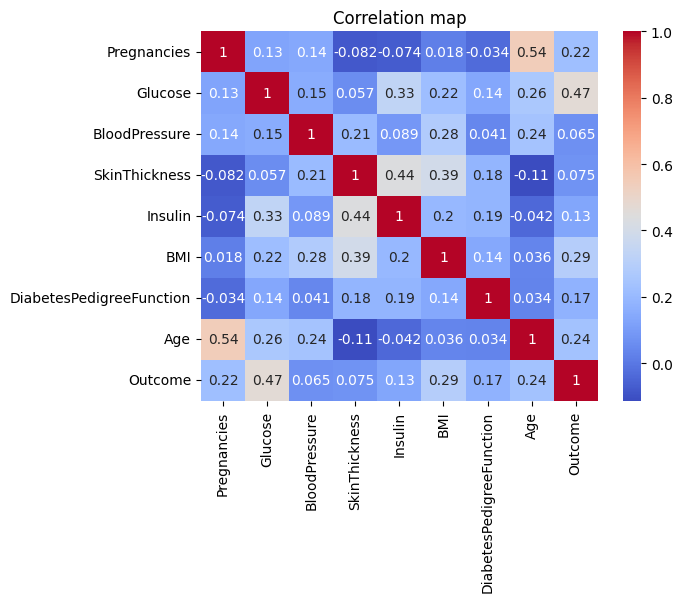

In [5]:
df_corr = df.corr()
df_corr

plt.Figure(figsize=(90,90))
sns.heatmap(df_corr,annot=True,cmap="coolwarm")
plt.title("Correlation map")
plt.show()

In [6]:
x= df.drop(columns=['Outcome'])
y = df['Outcome']

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
model =GaussianNB()
model.fit(x_train,y_train)


,priors,None
,var_smoothing,1e-09


In [10]:
y_pred = model.predict(x_test)

accu = accuracy_score(y_test,y_pred)
print(f'accuracy = {accu}')
cm = confusion_matrix(y_test,y_pred)
print(f'Confusion matrix = {cm}')
cr = classification_report(y_test,y_pred)
print(f'classification_report = {cr}')

accuracy = 0.7662337662337663
Confusion matrix = [[79 20]
 [16 39]]
classification_report =               precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



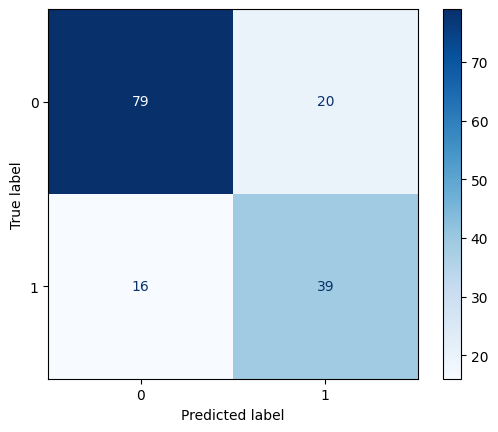

In [ ]:
cm = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
cm.plot(cmap=plt.cm.b)
plt.show()